In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

train = pd.read_csv("train.csv")   # has Survived
test  = pd.read_csv("test.csv")    # no Survived

X = train.drop(columns=["Survived"])
y = train["Survived"]

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = X_tr.copy()
train_df["Survived"] = y_tr.values


In [22]:
#Getting to know our data..
train_df.info()
train_df.describe(include="all")
(train_df.isna().mean().sort_values(ascending=False) * 100).round(2)


<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
 11  Survived     712 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


Cabin          77.53
Age            19.24
Embarked        0.28
PassengerId     0.00
Sex             0.00
Name            0.00
Pclass          0.00
SibSp           0.00
Ticket          0.00
Parch           0.00
Fare            0.00
Survived        0.00
dtype: float64

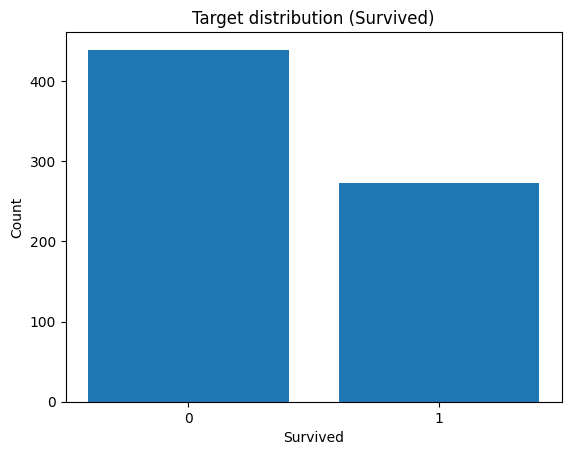

Survival rate: 0.38342696629213485


In [23]:
#Taking a look at the distribution of our target variable
import matplotlib.pyplot as plt

counts = train_df["Survived"].value_counts().sort_index()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Target distribution (Survived)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

print("Survival rate:", train_df["Survived"].mean())

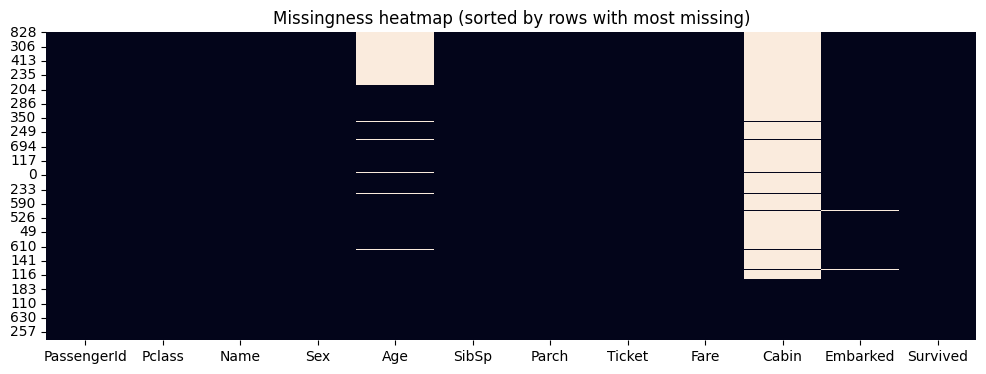

In [24]:
#Exploring missingness
import seaborn as sns

miss = train_df.isna()
miss_sorted = miss.loc[miss.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12, 4))
sns.heatmap(miss_sorted, cbar=False)
plt.title("Missingness heatmap (sorted by rows with most missing)")
plt.show()

In [25]:
def missing_rate_vs_target(df, col, target="Survived"):
    flag = df[col].isna().astype(int)
    return df.groupby(flag)[target].mean()

print("Cabin missingness vs survival:\n", missing_rate_vs_target(train_df, "Cabin"))
print("Age missingness vs survival:\n", missing_rate_vs_target(train_df, "Age"))
print("Embarked missingness vs survival:\n", missing_rate_vs_target(train_df, "Embarked"))

Cabin missingness vs survival:
 Cabin
0    0.700000
1    0.291667
Name: Survived, dtype: float64
Age missingness vs survival:
 Age
0    0.405217
1    0.291971
Name: Survived, dtype: float64
Embarked missingness vs survival:
 Embarked
0    0.38169
1    1.00000
Name: Survived, dtype: float64



 Age
count    575.000000
mean      29.807687
std       14.485211
min        0.420000
25%       21.000000
50%       28.500000
75%       39.000000
max       80.000000
Name: Age, dtype: float64


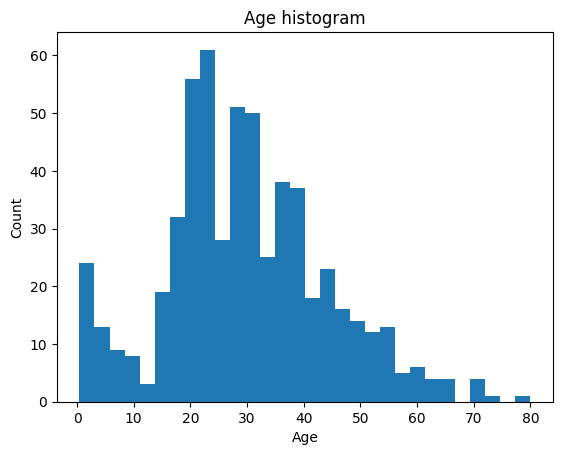

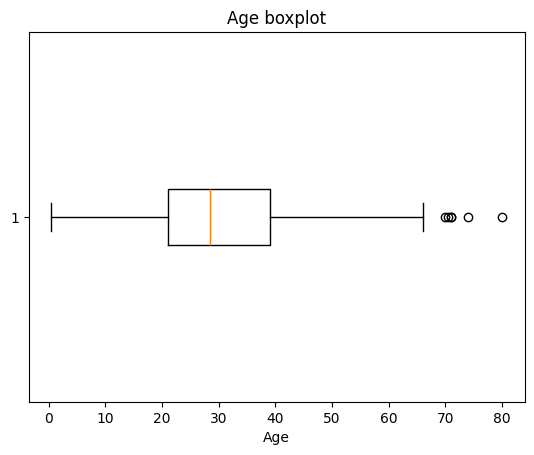


 Fare
count    712.000000
mean      31.819826
std       48.059104
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


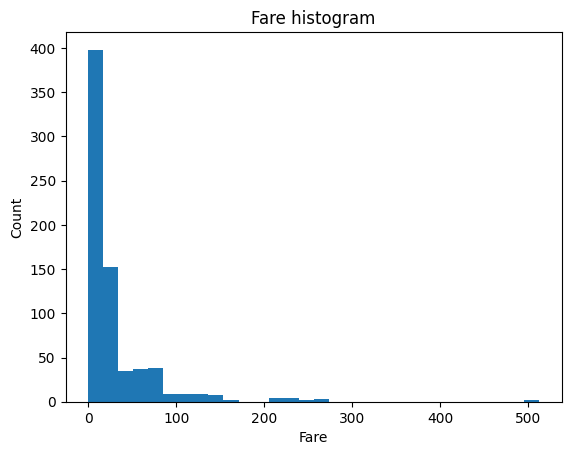

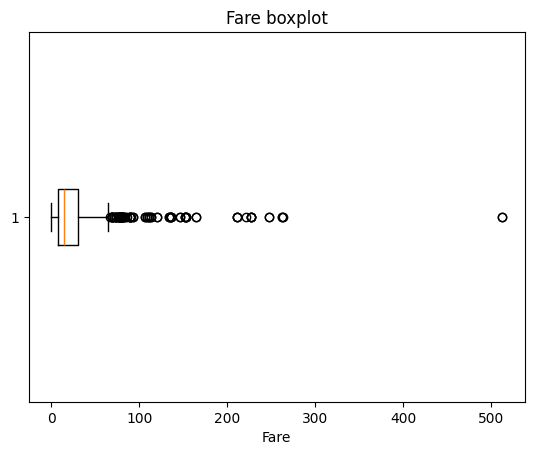


 SibSp
count    712.000000
mean       0.492978
std        1.060720
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64


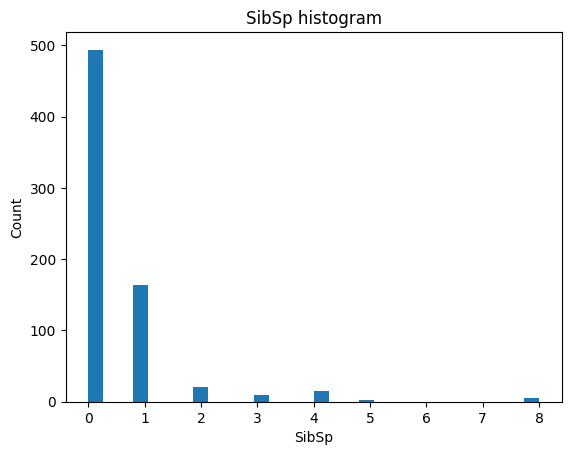

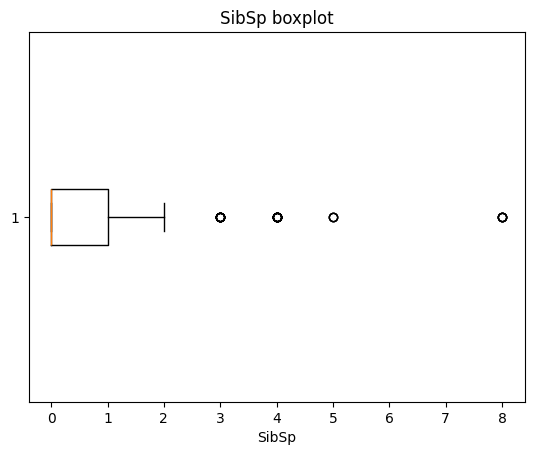


 Parch
count    712.000000
mean       0.390449
std        0.838134
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64


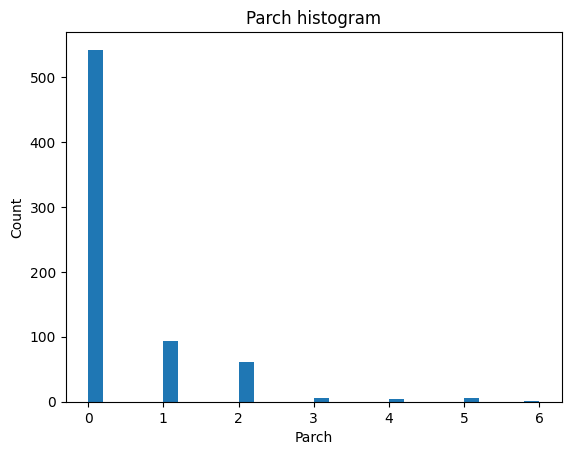

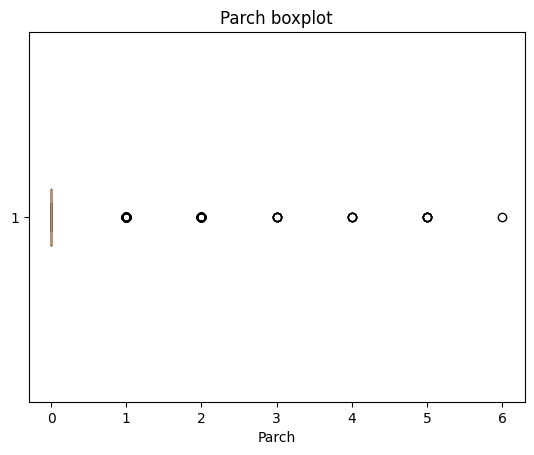

In [26]:
#Univariate analysis of numerical features
def univariate_numeric(df, col):
    s = df[col].dropna()
    print("\n", col)
    print(s.describe())

    plt.figure()
    plt.hist(s, bins=30)
    plt.title(f"{col} histogram")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

    plt.figure()
    plt.boxplot(s, vert=False)
    plt.title(f"{col} boxplot")
    plt.xlabel(col)
    plt.show()

for c in ["Age","Fare","SibSp","Parch"]:
    univariate_numeric(train_df, c)



 Sex
Sex
male      459
female    253
Name: count, dtype: int64


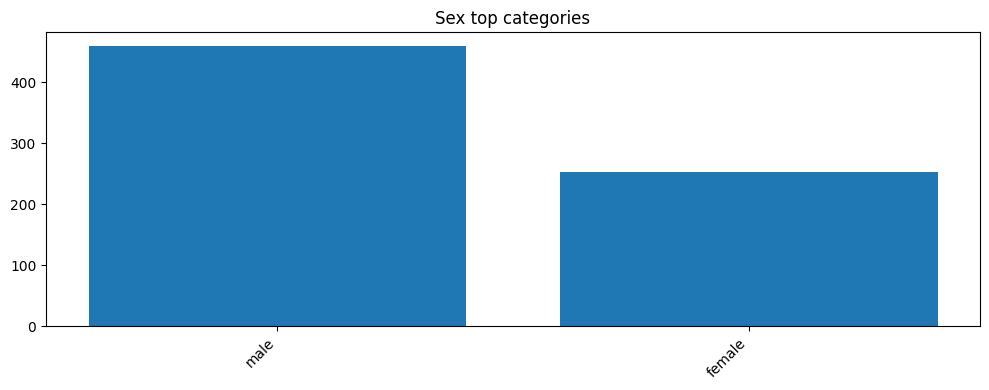


 Embarked
Embarked
S      516
C      139
Q       55
NaN      2
Name: count, dtype: int64


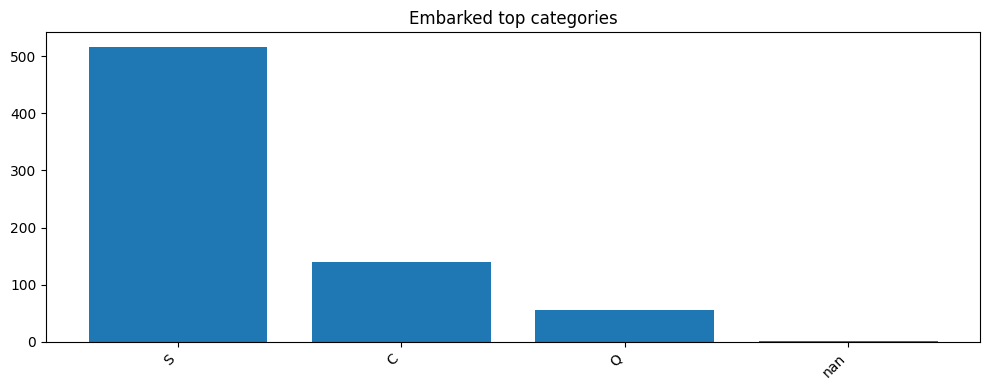


 Pclass
Pclass
3    391
1    171
2    150
Name: count, dtype: int64


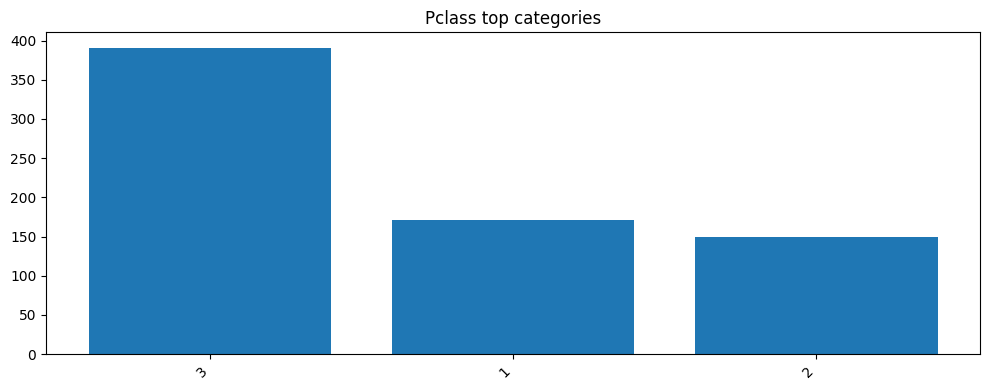

In [27]:
#Univariate analysis of categorical features
def univariate_categorical(df, col, top_n=20):
    vc = df[col].value_counts(dropna=False).head(top_n)
    print("\n", col)
    print(vc)

    plt.figure(figsize=(10,4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f"{col} top categories")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for c in ["Sex","Embarked","Pclass"]:
    univariate_categorical(train_df, c)


        count  survival_rate
Sex                         
female    253       0.743083
male      459       0.185185


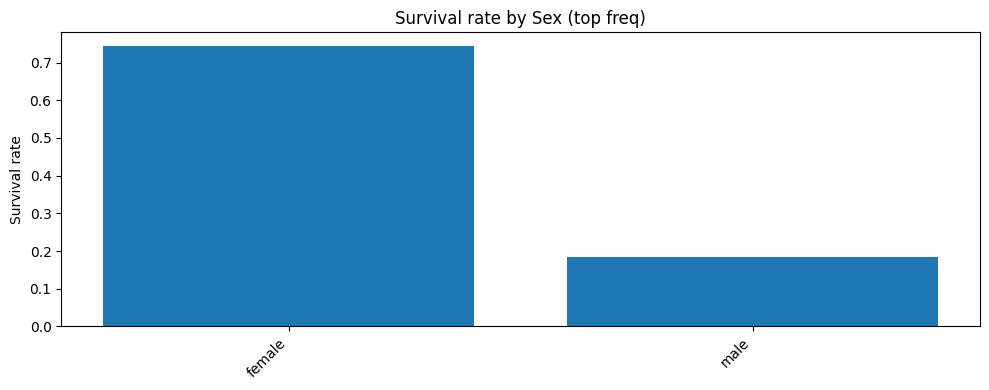

        count  survival_rate
Pclass                      
1         171       0.649123
2         150       0.446667
3         391       0.242967


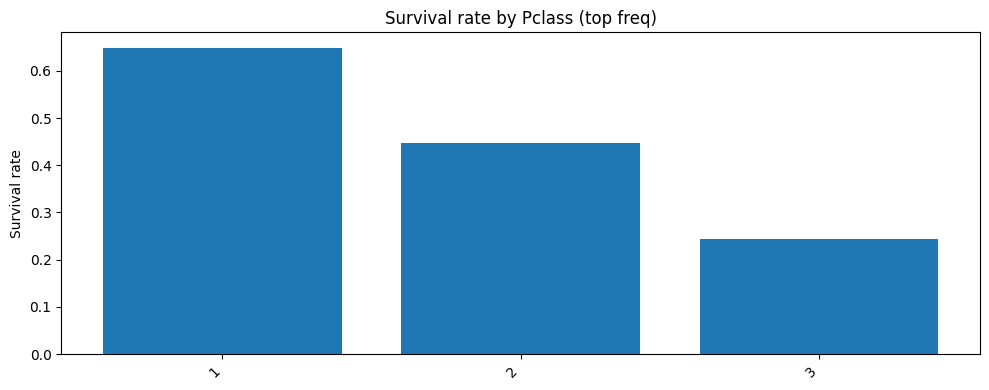

          count  survival_rate
Embarked                      
C           139       0.561151
Q            55       0.436364
S           516       0.327519
NaN           2       1.000000


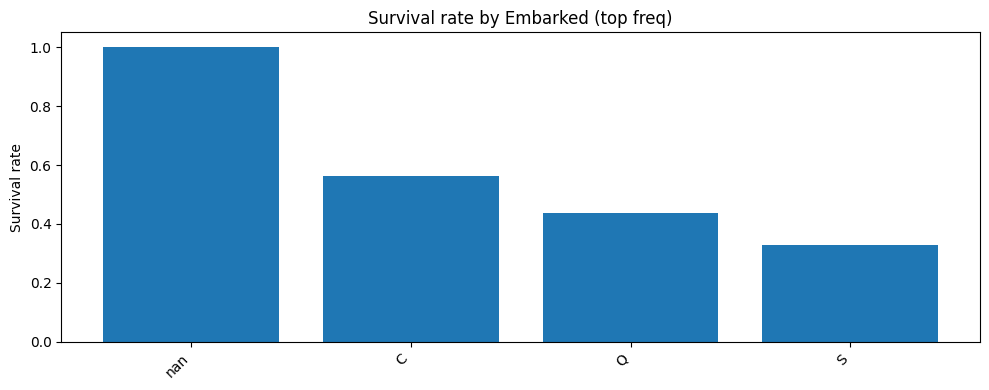

In [28]:
#Bivariate analysis: Categorical vs target
def cat_vs_target(df, feature, target="Survived"):
    rate = df.groupby(feature, dropna=False)[target].mean().sort_values(ascending=False)
    cnt  = df[feature].value_counts(dropna=False)
    out = pd.DataFrame({"count": cnt, "survival_rate": rate})
    print(out)

    keep = cnt.head(15).index
    plot = out.loc[keep].sort_values("survival_rate", ascending=False)

    plt.figure(figsize=(10,4))
    plt.bar(plot.index.astype(str), plot["survival_rate"].values)
    plt.title(f"Survival rate by {feature} (top freq)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Survival rate")
    plt.tight_layout()
    plt.show()

for c in ["Sex","Pclass","Embarked"]:
    cat_vs_target(train_df, c)


C:\Users\mahdi\AppData\Local\Temp\ipykernel_14136\3513552970.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0, s1], labels=["0","1"], vert=False)


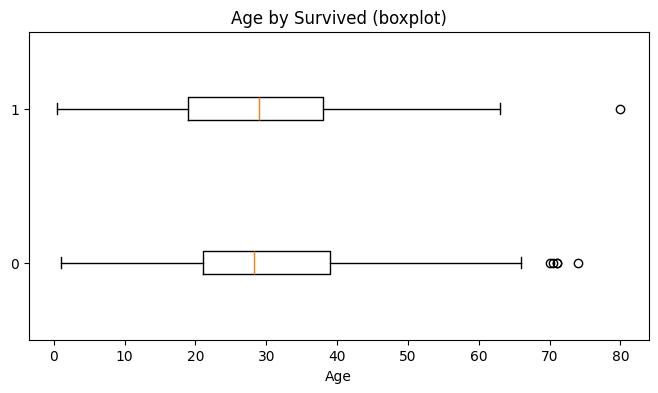

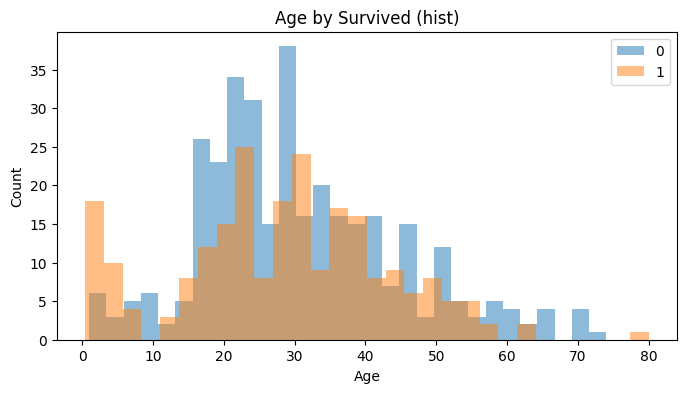

C:\Users\mahdi\AppData\Local\Temp\ipykernel_14136\3513552970.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0, s1], labels=["0","1"], vert=False)


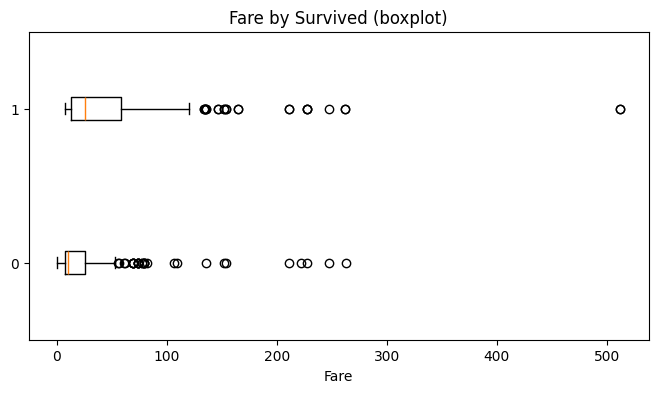

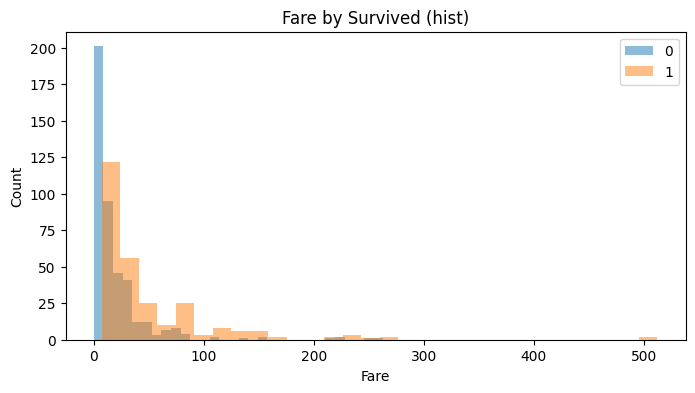

C:\Users\mahdi\AppData\Local\Temp\ipykernel_14136\3513552970.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0, s1], labels=["0","1"], vert=False)


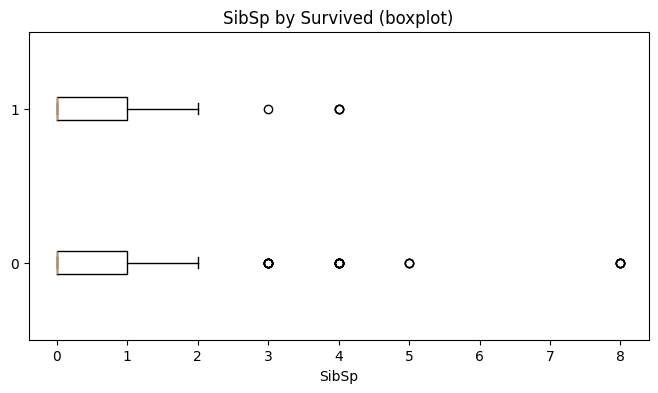

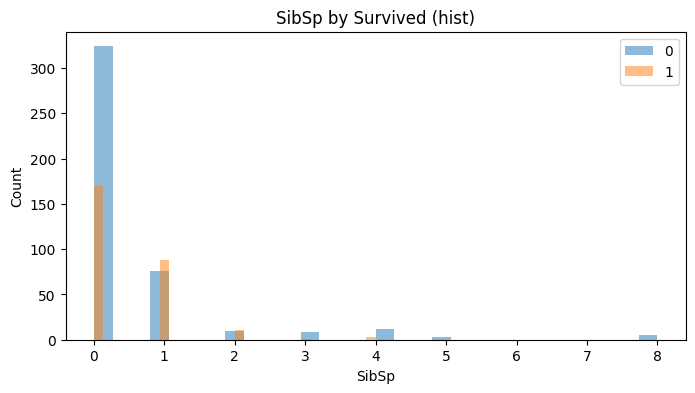

C:\Users\mahdi\AppData\Local\Temp\ipykernel_14136\3513552970.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0, s1], labels=["0","1"], vert=False)


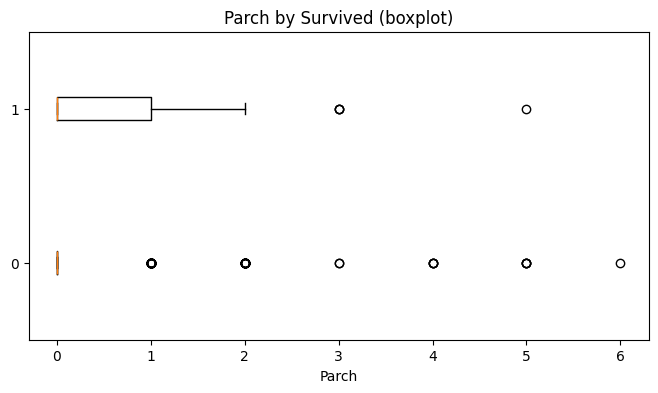

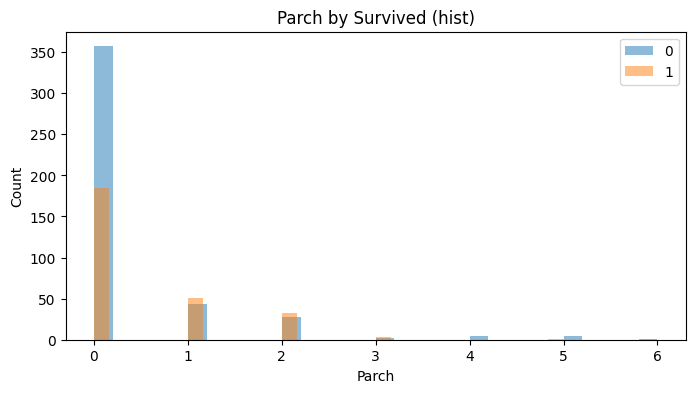

In [29]:
#Bivariate analysis: Numerical vs target
def num_vs_target(df, feature, target="Survived"):
    s0 = df.loc[df[target]==0, feature].dropna()
    s1 = df.loc[df[target]==1, feature].dropna()

    plt.figure(figsize=(8,4))
    plt.boxplot([s0, s1], labels=["0","1"], vert=False)
    plt.title(f"{feature} by {target} (boxplot)")
    plt.xlabel(feature)
    plt.show()

    plt.figure(figsize=(8,4))
    plt.hist(s0, bins=30, alpha=0.5, label="0")
    plt.hist(s1, bins=30, alpha=0.5, label="1")
    plt.title(f"{feature} by {target} (hist)")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

for c in ["Age","Fare","SibSp","Parch"]:
    num_vs_target(train_df, c)



Rates:
 Sex       female      male
Pclass                    
1       0.974684  0.369565
2       0.913793  0.152174
3       0.500000  0.134545
Counts:
 Sex     female  male
Pclass              
1           79    92
2           58    92
3          116   275


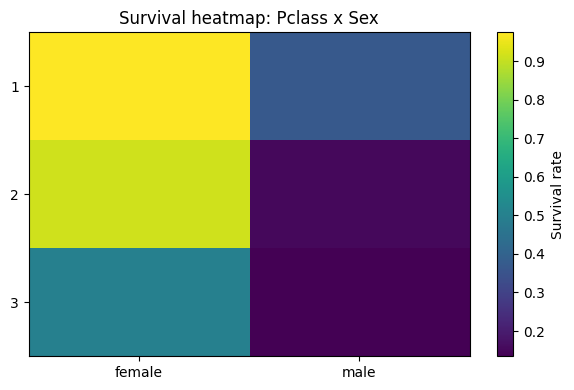

In [30]:
#Checking for relationships between features
pivot = train_df.pivot_table(values="Survived", index="Pclass", columns="Sex", aggfunc="mean")
counts = train_df.pivot_table(values="Survived", index="Pclass", columns="Sex", aggfunc="size")
print("Rates:\n", pivot)
print("Counts:\n", counts)

plt.figure(figsize=(6,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(pivot.shape[1]), pivot.columns.astype(str))
plt.yticks(range(pivot.shape[0]), pivot.index.astype(str))
plt.colorbar(label="Survival rate")
plt.title("Survival heatmap: Pclass x Sex")
plt.tight_layout()
plt.show()


Rates:
 Embarked         C         Q         S
Pclass                                
1         0.702703  1.000000  0.595745
2         0.500000  0.500000  0.441176
3         0.377358  0.423077  0.185315
Counts:
 Embarked   C   Q    S
Pclass               
1         74   1   94
2         12   2  136
3         53  52  286


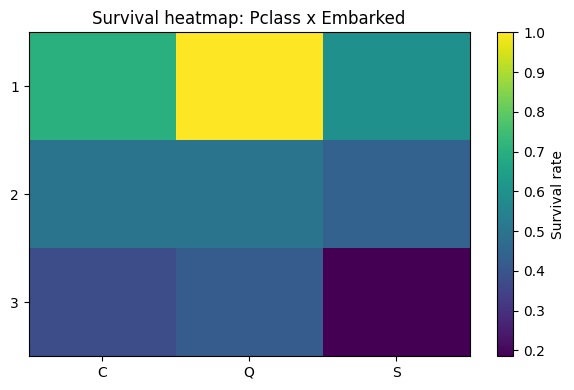

In [31]:
pivot = train_df.pivot_table(values="Survived", index="Pclass", columns="Embarked", aggfunc="mean")
counts = train_df.pivot_table(values="Survived", index="Pclass", columns="Embarked", aggfunc="size")
print("Rates:\n", pivot)
print("Counts:\n", counts)

plt.figure(figsize=(6,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(pivot.shape[1]), pivot.columns.astype(str))
plt.yticks(range(pivot.shape[0]), pivot.index.astype(str))
plt.colorbar(label="Survival rate")
plt.title("Survival heatmap: Pclass x Embarked")
plt.tight_layout()
plt.show()

            Age      Fare     SibSp     Parch
Age    1.000000  0.106915 -0.312885 -0.175573
Fare   0.106915  1.000000  0.127011  0.177235
SibSp -0.312885  0.127011  1.000000  0.392269
Parch -0.175573  0.177235  0.392269  1.000000
            Age      Fare     SibSp     Parch
Age    1.000000  0.124917 -0.179138 -0.249247
Fare   0.124917  1.000000  0.422945  0.405345
SibSp -0.179138  0.422945  1.000000  0.443166
Parch -0.249247  0.405345  0.443166  1.000000


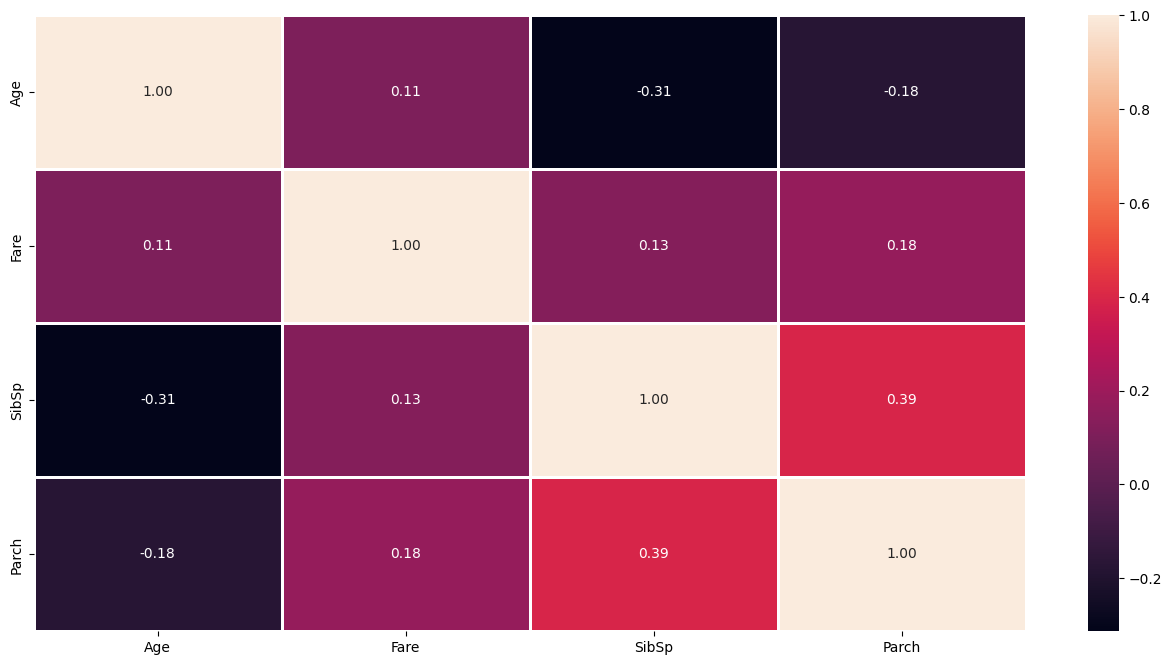

In [32]:
#Displaying the correlation matrix of numerical features
num_cols = ["Age","Fare","SibSp","Parch"]
corr = train_df[num_cols].corr(method="pearson")
print(corr)

corr_s = train_df[num_cols].corr(method="spearman")
print(corr_s)
fig, ax = plt.subplots(figsize = (16, 8))
sns.heatmap(corr, annot = True, fmt = '1.2f', annot_kws = {'size' : 10}, linewidth = 1)
plt.show()

In [33]:
# Cell 17: Missingness engineering + feature engineering (combined)
import numpy as np
import pandas as pd

def fit_missing_stats(df):
    stats = {}
    stats["age_med_by_sex_pclass"] = df.groupby(["Sex", "Pclass"])["Age"].median()
    stats["age_med_global"] = df["Age"].median()

    stats["fare_med_by_pclass"] = df.groupby("Pclass")["Fare"].median()
    stats["fare_med_global"] = df["Fare"].median()

    stats["embarked_mode"] = df["Embarked"].mode(dropna=True).iloc[0]
    return stats

def apply_missing(df, stats):
    out = df.copy()

    # Age: grouped median -> global fallback
    idx = out.set_index(["Sex", "Pclass"]).index
    age_fill = pd.Series(idx.map(stats["age_med_by_sex_pclass"]), index=out.index)
    out["Age"] = out["Age"].fillna(age_fill).fillna(stats["age_med_global"])

    # Fare: by Pclass -> global fallback
    out["Fare"] = out["Fare"].fillna(out["Pclass"].map(stats["fare_med_by_pclass"]))
    out["Fare"] = out["Fare"].fillna(stats["fare_med_global"])

    # Embarked: mode
    out["Embarked"] = out["Embarked"].fillna(stats["embarked_mode"])

    # Cabin: keep missingness as explicit category
    out["Cabin"] = out["Cabin"].fillna("Unknown")
    return out

def add_family(df):
    df = df.copy()
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    return df

def add_title(df):
    df = df.copy()
    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
    title_map = {
        "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
        "Lady": "Royalty", "Countess": "Royalty", "Sir": "Royalty",
        "Jonkheer": "Royalty", "Don": "Royalty", "Dona": "Royalty",
        "Dr": "Officer", "Rev": "Officer", "Col": "Officer",
        "Major": "Officer", "Capt": "Officer"
    }
    df["Title"] = df["Title"].replace(title_map)
    rare = df["Title"].value_counts()
    df.loc[df["Title"].isin(rare[rare < 10].index), "Title"] = "Rare"
    return df

def add_cabin(df):
    df = df.copy()
    cabin_clean = df["Cabin"].astype(str).str.strip()
    df["HasCabin"] = ((df["Cabin"].notna()) & (cabin_clean.str.lower() != "unknown") & (cabin_clean != "")).astype(int)
    df["Deck"] = cabin_clean.str[0]
    df.loc[(df["Cabin"].isna()) | (cabin_clean.str.lower() == "unknown") | (cabin_clean == ""), "Deck"] = "Unknown"
    return df

def add_ticket(df):
    df = df.copy()
    t = df["Ticket"].astype(str)
    prefix = t.str.replace(r"\d+", "", regex=True)
    prefix = prefix.str.replace(r"[./]", "", regex=True).str.strip()
    df["TicketPrefix"] = prefix.replace("", "NONE")
    return df

def add_fare_transform(df):
    df = df.copy()
    df["FareLog"] = np.log1p(df["Fare"])
    return df

def add_age_transform(df):
    df = df.copy()
    df["AgeBin"] = pd.cut(
        df["Age"],
        bins=[0, 12, 18, 30, 50, np.inf],
        labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
    )
    return df

def fe_all(df):
    df = df.copy()
    df = add_family(df)
    df = add_title(df)
    df = add_cabin(df)
    df = add_ticket(df)
    df = add_fare_transform(df)
    df = add_age_transform(df)
    df = df.drop(columns=["Name", "Ticket", "Cabin", "PassengerId"], errors="ignore")
    return df

# Fit missingness stats on training split only (avoid leakage)
miss_stats = fit_missing_stats(X_tr)

# Apply missingness handling
X_tr_imp = apply_missing(X_tr, miss_stats)
X_va_imp = apply_missing(X_va, miss_stats)
test_imp = apply_missing(test, miss_stats)

# Apply feature engineering
X_tr_fe = fe_all(X_tr_imp)
X_va_fe = fe_all(X_va_imp)
test_fe = fe_all(test_imp)

X_tr_fe.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,HasCabin,Deck,TicketPrefix,FareLog,AgeBin
692,3,male,26.0,0,0,56.4958,S,1,1,Mr,0,Unknown,NONE,4.051712,YoungAdult
481,2,male,30.0,0,0,0.0000,S,1,1,Mr,0,Unknown,NONE,0.000000,YoungAdult
527,1,male,40.0,0,0,221.7792,S,1,1,Mr,1,C,PC,5.406181,Adult
855,3,female,18.0,0,1,9.3500,S,2,0,Mrs,0,Unknown,NONE,2.336987,Teen
801,2,female,31.0,1,1,26.2500,S,3,0,Mrs,0,Unknown,CA,3.305054,Adult


In [5]:
# Cell 14: Optimized XGBoost with stratified 5-fold CV and OOF threshold tuning

import numpy as np

import pandas as pd



from scipy.stats import randint, uniform



from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.impute import SimpleImputer

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import accuracy_score



from xgboost import XGBClassifier



SEED = 42



# Make this cell runnable even after a kernel restart.

if "train" not in globals() or "test" not in globals():

    train = pd.read_csv("train.csv")

    test = pd.read_csv("test.csv")



class TitanicFeatureBuilder(BaseEstimator, TransformerMixin):

    def __init__(self, rare_threshold=10):

        self.rare_threshold = rare_threshold



    def fit(self, X, y=None):

        X = X.copy()

        self.age_med_by_sex_pclass_ = X.groupby(["Sex", "Pclass"])["Age"].median()

        self.age_med_global_ = X["Age"].median()



        self.fare_med_by_pclass_ = X.groupby("Pclass")["Fare"].median()

        self.fare_med_global_ = X["Fare"].median()



        embarked_mode = X["Embarked"].mode(dropna=True)

        self.embarked_mode_ = embarked_mode.iloc[0] if len(embarked_mode) > 0 else "S"



        title_raw = self._extract_title(X)

        title_mapped = title_raw.replace(self._title_map())

        vc = title_mapped.value_counts(dropna=False)

        self.common_titles_ = set(vc[vc >= self.rare_threshold].index.astype(str))

        return self



    def transform(self, X):

        X = X.copy()



        idx = X.set_index(["Sex", "Pclass"]).index

        age_fill = pd.Series(idx.map(self.age_med_by_sex_pclass_), index=X.index)

        X["Age"] = X["Age"].fillna(age_fill).fillna(self.age_med_global_)



        X["Fare"] = X["Fare"].fillna(X["Pclass"].map(self.fare_med_by_pclass_))

        X["Fare"] = X["Fare"].fillna(self.fare_med_global_)

        X["Embarked"] = X["Embarked"].fillna(self.embarked_mode_)

        X["Cabin"] = X["Cabin"].fillna("Unknown")



        X["FamilySize"] = X["SibSp"] + X["Parch"] + 1

        X["IsAlone"] = (X["FamilySize"] == 1).astype(int)

        X["FarePerPerson"] = X["Fare"] / X["FamilySize"].clip(lower=1)

        X["SexPclass"] = X["Sex"].astype(str) + "_" + X["Pclass"].astype(str)



        title = self._extract_title(X).replace(self._title_map()).fillna("Unknown").astype(str)

        X["Title"] = np.where(title.isin(self.common_titles_), title, "Rare")



        cabin_clean = X["Cabin"].astype(str).str.strip()

        X["HasCabin"] = (

            X["Cabin"].notna() & (cabin_clean.str.lower() != "unknown") & (cabin_clean != "")

        ).astype(int)

        X["Deck"] = cabin_clean.str[0]

        X.loc[

            (X["Cabin"].isna()) | (cabin_clean.str.lower() == "unknown") | (cabin_clean == ""),

            "Deck",

        ] = "Unknown"



        t = X["Ticket"].astype(str)

        prefix = t.str.replace(r"\d+", "", regex=True)

        prefix = prefix.str.replace(r"[./]", "", regex=True).str.strip()

        X["TicketPrefix"] = prefix.replace("", "NONE")

        X["TicketGroupSize"] = t.map(t.value_counts())



        surname = X["Name"].astype(str).str.split(",").str[0].str.strip()

        X["SurnameGroupSize"] = surname.map(surname.value_counts())



        X["FareLog"] = np.log1p(X["Fare"])

        X["AgeBin"] = pd.cut(

            X["Age"],

            bins=[0, 12, 18, 30, 50, np.inf],

            labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],

        ).astype(str)



        X = X.drop(columns=["Name", "Ticket", "Cabin", "PassengerId"], errors="ignore")

        return X



    @staticmethod

    def _extract_title(df):

        return df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()



    @staticmethod

    def _title_map():

        return {

            "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",

            "Lady": "Royalty", "Countess": "Royalty", "Sir": "Royalty",

            "Jonkheer": "Royalty", "Don": "Royalty", "Dona": "Royalty",

            "Dr": "Officer", "Rev": "Officer", "Col": "Officer",

            "Major": "Officer", "Capt": "Officer",

        }



def make_ohe():

    try:

        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    except TypeError:

        return OneHotEncoder(handle_unknown="ignore", sparse=False)



preprocess = ColumnTransformer(

    transformers=[

        (

            "num",

            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),

            make_column_selector(dtype_include=np.number),

        ),

        (

            "cat",

            Pipeline(

                steps=[

                    ("imputer", SimpleImputer(strategy="most_frequent")),

                    ("onehot", make_ohe()),

                ]

            ),

            make_column_selector(dtype_exclude=np.number),

        ),

    ],

    remainder="drop",

)



xgb_pipeline = Pipeline(

    steps=[

        ("feat", TitanicFeatureBuilder()),

        ("prep", preprocess),

        (

            "model",

            XGBClassifier(

                objective="binary:logistic",

                eval_metric="logloss",

                random_state=SEED,

                n_estimators=400,

                learning_rate=0.05,

                max_depth=4,

                min_child_weight=2,

                subsample=0.9,

                colsample_bytree=0.9,

                gamma=0.0,

                reg_alpha=0.0,

                reg_lambda=1.0,

                n_jobs=-1,

                tree_method="hist",

            ),

        ),

    ]

)



X_all = train.drop(columns=["Survived"])

y_all = train["Survived"].astype(int)



cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)



param_dist = {

    "model__n_estimators": randint(300, 1801),

    "model__max_depth": randint(3, 9),

    "model__learning_rate": uniform(0.01, 0.14),

    "model__min_child_weight": randint(1, 9),

    "model__subsample": uniform(0.6, 0.4),

    "model__colsample_bytree": uniform(0.6, 0.4),

    "model__gamma": uniform(0.0, 0.4),

    "model__reg_alpha": uniform(0.0, 1.0),

    "model__reg_lambda": uniform(0.5, 2.5),

}



search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=param_dist,

    n_iter=50,

    scoring="accuracy",

    cv=cv,

    random_state=SEED,

    n_jobs=-1,

    verbose=1,

    refit=True,

)



search.fit(X_all, y_all)

best_xgb = search.best_estimator_



print("Best CV accuracy:", round(search.best_score_, 5))

print("Best params:")

for k, v in search.best_params_.items():

    print(f"  {k}: {v}")



# OOF threshold tuning on the best XGBoost pipeline.

oof_proba = cross_val_predict(

    best_xgb,

    X_all,

    y_all,

    cv=cv,

    method="predict_proba",

    n_jobs=-1,

)[:, 1]



thresholds = np.linspace(0.30, 0.70, 81)

acc_curve = [accuracy_score(y_all, (oof_proba >= t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(acc_curve))

best_threshold = float(thresholds[best_idx])

best_oof_acc = float(acc_curve[best_idx])



print(f"Best OOF threshold: {best_threshold:.3f}")

print(f"Best OOF accuracy at threshold: {best_oof_acc:.5f}")



best_xgb.fit(X_all, y_all)

test_proba = best_xgb.predict_proba(test)[:, 1]

test_pred = (test_proba >= best_threshold).astype(int)



submission_xgb_tuned_cv5 = pd.DataFrame(

    {"PassengerId": test["PassengerId"], "Survived": test_pred}

)

submission_xgb_tuned_cv5.to_csv("submission_xgb_tuned_cv5.csv", index=False)



print("Saved: submission_xgb_tuned_cv5.csv")

submission_xgb_tuned_cv5.head()


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV accuracy: 0.8451
Best params:
  model__colsample_bytree: 0.9227651908203118
  model__gamma: 0.13852172843576033
  model__learning_rate: 0.0750543338115456
  model__max_depth: 7
  model__min_child_weight: 7
  model__n_estimators: 821
  model__reg_alpha: 0.9491457315913859
  model__reg_lambda: 2.716700968245119
  model__subsample: 0.7043574493366855
Best OOF threshold: 0.520
Best OOF accuracy at threshold: 0.84736
Saved: submission_xgb_tuned_cv5.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
